In [158]:
import tensorflow as tf

In [159]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# 1. Load the data
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"x_train shape: {x_train.shape}")  # (60000, 28, 28)
print(x_train[1])  # (28, 28)

print(f"y_train shape: {y_train.shape}")  # (60000,)
print(y_train[:10])  # [0 1 2 3 4 5 6 7 8 9]

# 2. Perform One-Hot Encoding
# We specify num_classes=10 because there are 10 digits (0-9)
y_train_one_hot = to_categorical(y_train, num_classes=10)
y_test_one_hot = to_categorical(y_test, num_classes=10)

# 3. Check the new shapes
print(f"Original label shape: {y_train.shape}")         # (60000,)
print(f"One-hot label shape: {y_train_one_hot.shape}")   # (60000, 10)

# 4. See the difference in a single label
print(f"Original first label: {y_train[0]}")            # 5
print(f"One-hot first label: {y_train_one_hot[0]}")      # [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

x_train shape: (60000, 28, 28)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253
  159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252
  252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239
  233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202
   84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0

In [ ]:
print(x_train[0].shape)
print(y_train.shape)
print(y_train_one_hot.shape)
print(y_train_one_hot[0])

(28, 28)
(60000,)


In [161]:
import numpy as np
from matplotlib import pyplot as plt

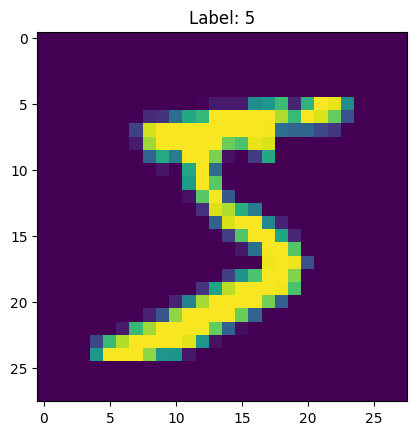

In [162]:
# Select the first image
first_image = x_train[0]

# Display it
# 'gray_r' (reversed) often looks better as it shows black ink on white paper
plt.imshow(first_image) 
plt.title(f"Label: {y_train[0]}") # Show the label so you can verify
plt.show()

In [163]:
tf.random.normal([784,256]).numpy().shape

(784, 256)

In [ ]:
n_input = 28 * 28 # 784
n_hidden_1= 256
n_hidden_2 = 256
n_output = 10

weights = {
    'h1': tf.Variable(tf.random.normal([n_input, n_hidden_1])), # (784, 256)
    'h2': tf.Variable(tf.random.normal([n_hidden_1, n_hidden_2])), # (256, 256)
    'out': tf.Variable(tf.random.normal([n_hidden_2, n_output])) # (256, 10)
}
print(weights['h1'].shape)

biases = {
    'b1': tf.Variable(tf.random.normal([n_hidden_1])),
    'b2': tf.Variable(tf.random.normal([n_hidden_2])),
    'out': tf.Variable(tf.random.normal([n_output]))
}
print(biases['b1'].shape)

(784, 256)
(256,)


In [165]:
def forward_pass(x, weights, biases):

    # Hidden layer 1
    z1 = tf.add(tf.matmul(x, weights['h1']), biases['b1'])
    a1 = tf.nn.relu(z1)
    
    # Hidden layer 2
    z2 = tf.add(tf.matmul(a1, weights['h2']), biases['b2'])
    a2 = tf.nn.relu(z2)
    
    # Output layer
    z_out = tf.add(tf.matmul(a2, weights['out']), biases['out'])
    
    return z_out

In [166]:
# 1. Prepare the data (Equivalent to the old feed_dict logic)
# We flatten the test images: from (10000, 28, 28) to (10000, 784)
# We also cast to float32 and normalize (divide by 255)
x_train_flattened = tf.cast(x_train.reshape(-1, 784), tf.float32) / 255.0
x_test_flattened = tf.cast(x_test.reshape(-1, 784), tf.float32) / 255.0


# 2. Run the Forward Pass (No sess.run needed!)
# This runs the math immediately (Eager Execution)
pred = forward_pass(x_train_flattened, weights, biases)

# 3. Get the Predicted Class (Equivalent to tf.argmax)
# axis=1 means "find the highest score in each row"
predictions_eval = tf.argmax(pred, axis=1).numpy()

# 4. Show the result (Equivalent to Out[59])
print(f"Predicted labels: {predictions_eval}")
print(f"True labels: {y_train}")
print(f"correct predictions: {(predictions_eval == y_train).sum()} out of {len(y_train)}")

Predicted labels: [3 3 3 ... 3 3 1]
True labels: [5 0 4 ... 5 6 8]
correct predictions: 8762 out of 60000


In [167]:
cross_entropy = tf.nn.softmax_cross_entropy_with_logits(labels=y_train_one_hot, logits=pred)
print(f"Cross-entropy shape: {cross_entropy.shape}")  # Should be (60000,)
cost = tf.reduce_mean(cross_entropy).numpy()
print(f"Mean cross-entropy loss: {cost}")

Cross-entropy shape: (60000,)
Mean cross-entropy loss: 2034.444580078125


In [170]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)


@tf.function 
def train_step(x_batch, y_batch, weights, biases):
    # 1. Flatten all dict values into a single list of variables
    # This ensures the optimizer sees [h1, h2, out, b1, b2, out]
    trainable_vars = list(weights.values()) + list(biases.values())
    
    with tf.GradientTape() as tape:
        # Forward Pass
        pred = forward_pass(x_batch, weights, biases)
        
        # Loss Calculation
        cross_entropy = tf.nn.softmax_cross_entropy_with_logits(labels=y_batch, logits=pred)
        cost = tf.reduce_mean(cross_entropy)
        
    # 2. Calculate gradients for the flat list
    gradients = tape.gradient(cost, trainable_vars)
    # 3. Apply gradients to the flat list
    optimizer.apply_gradients(zip(gradients, trainable_vars))
    
    return cost

In [172]:
batch_size = 100

for i in range(25):  
    num_batches = len(x_train_flattened) // batch_size
    toatal_cost = 0
    for batch in range(num_batches):
        start = batch * batch_size
        end = start + batch_size
        x_batch = x_train_flattened[start:end]
        y_batch = y_train_one_hot[start:end]
        current_cost = train_step(x_batch, y_batch, weights, biases)
        toatal_cost += current_cost.numpy()
    print(f"Epoch {i+1}, Average Cost: {toatal_cost}")

# After training, we can evaluate accuracy again
pred_after_training = forward_pass(x_test_flattened, weights, biases)
predictions_after_training = tf.argmax(pred_after_training, axis=1).numpy()
print(f"Predicted labels after training: {predictions_after_training}")
print(f"True labels: {y_test}")
print(f"correct predictions after training: {(predictions_after_training == y_test).sum()} out of {len(y_test)}")

Epoch 1, Average Cost: 202.20265197753906
Epoch 2, Average Cost: 176.06651306152344
Epoch 3, Average Cost: 174.08328247070312
Epoch 4, Average Cost: 214.24786376953125
Epoch 5, Average Cost: 162.63128662109375
Epoch 6, Average Cost: 130.6200408935547
Epoch 7, Average Cost: 171.14617919921875
Epoch 8, Average Cost: 147.63172912597656
Epoch 9, Average Cost: 158.29208374023438
Epoch 10, Average Cost: 141.68356323242188
Epoch 11, Average Cost: 158.57139587402344
Epoch 12, Average Cost: 127.08524322509766
Epoch 13, Average Cost: 141.2496795654297
Epoch 14, Average Cost: 111.63674926757812
Epoch 15, Average Cost: 105.3873062133789
Epoch 16, Average Cost: 126.67647552490234
Epoch 17, Average Cost: 108.57372283935547
Epoch 18, Average Cost: 142.68032836914062
Epoch 19, Average Cost: 119.60030364990234
Epoch 20, Average Cost: 109.53520202636719
Epoch 21, Average Cost: 102.91004180908203
Epoch 22, Average Cost: 126.88834381103516
Epoch 23, Average Cost: 90.63011932373047
Epoch 24, Average Cost: 